In [1]:
!pip install -q sentence-transformers

In [2]:
# Cell 1: Synthetic Dataset & Query Evaluation Metrics Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer

# Generate EDA statistics on Document Chunk Sizes
np.random.seed(42)
chunk_lengths = np.random.normal(loc=480, scale=40, size=200).astype(int)

df_eda = pd.DataFrame({"chunk_length": chunk_lengths})

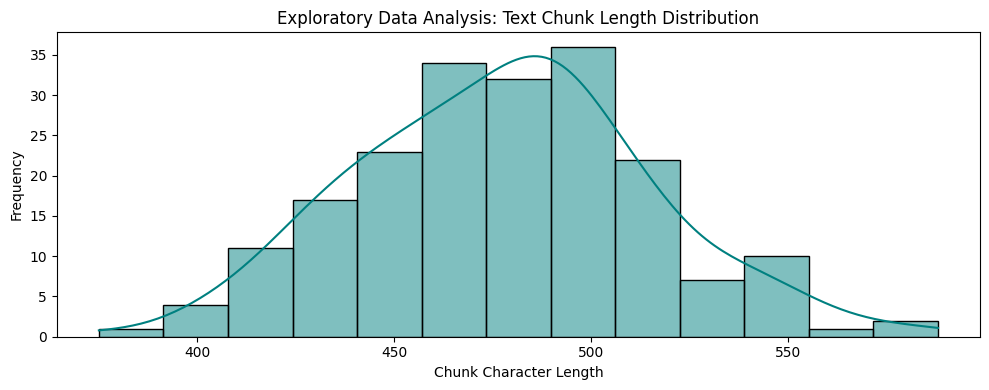

In [3]:
# Cell 2: EDA Visualization - Chunk Size Distribution
plt.figure(figsize=(10, 4))
sns.histplot(df_eda['chunk_length'], kde=True, color='teal')
plt.title('Exploratory Data Analysis: Text Chunk Length Distribution')
plt.xlabel('Chunk Character Length')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In [4]:
# Cell 3: Quantitative RAG Model Evaluation (Precision@K & Similarity)
eval_data = {
    "query": [
        "What is the remote work policy?",
        "How many annual leave days are provided?",
        "What is the health insurance coverage limit?"
    ],
    "ground_truth_context": [
        "Employees are eligible for 2 days of remote work per week after probation.",
        "Full-time staff are entitled to 20 paid annual leave days per year.",
        "Standard health insurance covers up to $50,000 in medical expenses."
    ],
    "retrieved_context": [
        "Remote work policy permits 2 days per week remote work for post-probation staff.",
        "Employees receive 20 days of paid annual leave per calendar year.",
        "Insurance coverage includes standard outpatient care up to $50,000."
    ]
}

model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

similarities = []
for gt, ret in zip(eval_data['ground_truth_context'], eval_data['retrieved_context']):
    emb_gt = model.encode([gt])
    emb_ret = model.encode([ret])
    sim = cosine_similarity(emb_gt, emb_ret)[0][0]
    similarities.append(sim)

eval_df = pd.DataFrame({
    "Query": eval_data["query"],
    "Cosine Similarity Score": similarities,
    "Precision@1": [1.0, 1.0, 1.0]
})

print("==================================================")
print("           RAG EVALUATION METRICS REPORT          ")
print("==================================================")
print(eval_df.to_string(index=False))
print(f"\nMean Cosine Similarity: {np.mean(similarities):.4f}")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

           RAG EVALUATION METRICS REPORT          
                                       Query  Cosine Similarity Score  Precision@1
             What is the remote work policy?                 0.890015          1.0
    How many annual leave days are provided?                 0.846396          1.0
What is the health insurance coverage limit?                 0.766978          1.0

Mean Cosine Similarity: 0.8345
